# RFI Detection Evaluation with IoU

This notebook explains how to evaluate burst-level RFI detections when predictions and annotations are represented as bounding boxes.

The example uses synthetic bursts, but the same metric logic applies to real RFInject outputs once detections are projected onto the burst image grid. It computes precision, recall, F1, and mean IoU of matched detections.


## Evaluation criteria

This notebook evaluates bounding-box detections at burst level by matching predicted boxes to ground-truth boxes using intersection over union (IoU).

It reports two complementary views:

- **Per-burst** precision, recall, and F1 for local error analysis.
- **Test-set aggregate** precision, recall, and F1 computed from total TP, FP, and FN across all bursts.

### 1) Box format and IoU

A box is represented as `[x1, y1, x2, y2]`. For prediction `P_j` and ground truth `G_i`:

$$
\mathrm{IoU}(G_i, P_j) = \frac{|G_i \cap P_j|}{|G_i| + |P_j| - |G_i \cap P_j|},\quad \mathrm{IoU}\in[0,1]
$$

IoU is `0` when boxes do not overlap and `1` when they coincide perfectly.

### 2) Match selection (greedy one-to-one matching)

Predictions in each burst are sorted by score descending, or kept in their input order if scores are absent. For each prediction in that order:

1. Find the unmatched ground-truth box with maximum IoU.
2. If IoU is at least `iou_threshold`, count the pair as one true positive and consume that ground-truth box.
3. Otherwise, count the prediction as a false positive.
4. Any ground-truth box never matched becomes a false negative.

This one-to-one rule prevents several predictions from claiming the same target.

### 3) Burst-level metrics

Let `TP_b`, `FP_b`, and `FN_b` be the counts for burst `b`.

$$
\mathrm{Precision}_b = \frac{TP_b}{TP_b+FP_b},\quad \text{if } TP_b+FP_b>0
$$

$$
\mathrm{Recall}_b = \frac{TP_b}{TP_b+FN_b},\quad \text{if } TP_b+FN_b>0
$$

$$
\mathrm{F1}_b = \frac{2\,\mathrm{Precision}_b\,\mathrm{Recall}_b}{\mathrm{Precision}_b+\mathrm{Recall}_b},\quad \text{if } \mathrm{Precision}_b+\mathrm{Recall}_b>0
$$

Mean IoU for matched pairs in burst `b` is:

$$
\overline{\mathrm{IoU}}_b = \frac{1}{|M_b|}\sum_{(i,j)\in M_b} \mathrm{IoU}(G_i,P_j)
$$

where `M_b` is the set of matched ground-truth and prediction pairs in burst `b`.

### 4) Test-set aggregation

Across all bursts:

$$
TP_{\mathrm{tot}} = \sum_b TP_b,
\\
FP_{\mathrm{tot}} = \sum_b FP_b,
\\
FN_{\mathrm{tot}} = \sum_b FN_b
$$

Then compute:

$$
\mathrm{Precision}_{\mathrm{test}} = \frac{TP_{\mathrm{tot}}}{TP_{\mathrm{tot}}+FP_{\mathrm{tot}}}
$$

$$
\mathrm{Recall}_{\mathrm{test}} = \frac{TP_{\mathrm{tot}}}{TP_{\mathrm{tot}}+FN_{\mathrm{tot}}}
$$

$$
\mathrm{F1}_{\mathrm{test}} = \frac{2\,\mathrm{Precision}_{\mathrm{test}}\,\mathrm{Recall}_{\mathrm{test}}}{\mathrm{Precision}_{\mathrm{test}}+\mathrm{Recall}_{\mathrm{test}}}
$$

These are micro-averaged dataset-level metrics, so they summarize detector behavior over the whole evaluation set rather than averaging burst scores equally.

### 5) Quality knobs

- `iou_threshold`: stricter matching if increased.
- Prediction scores: affect greedy order and therefore which matches are claimed first.
- Synthetic burst generation: changes the balance of TP, FP, and FN and therefore the difficulty of the evaluation task.

### 6) Interpretation

High precision with low recall indicates conservative detections: few false alarms, but many misses.

High recall with low precision indicates aggressive detections: many detections, but more false positives.


In [1]:
import numpy as np
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt


In [2]:
def iou_matrix(gt_boxes: np.ndarray, pred_boxes: np.ndarray) -> np.ndarray:
    """Pairwise IoU between ground truth and predicted boxes."""
    if gt_boxes.size == 0 or pred_boxes.size == 0:
        return np.zeros((len(gt_boxes), len(pred_boxes)), dtype=float)

    # [x1, y1, x2, y2]
    g = gt_boxes[:, None, :]
    p = pred_boxes[None, :, :]

    xA = np.maximum(g[..., 0], p[..., 0])
    yA = np.maximum(g[..., 1], p[..., 1])
    xB = np.minimum(g[..., 2], p[..., 2])
    yB = np.minimum(g[..., 3], p[..., 3])

    inter_w = np.maximum(0.0, xB - xA)
    inter_h = np.maximum(0.0, yB - yA)
    inter_area = inter_w * inter_h

    gt_area = np.maximum(0.0, g[..., 2] - g[..., 0]) * np.maximum(0.0, g[..., 3] - g[..., 1])
    pred_area = np.maximum(0.0, p[..., 2] - p[..., 0]) * np.maximum(0.0, p[..., 3] - p[..., 1])
    union_area = gt_area + pred_area - inter_area

    return np.where(union_area > 0.0, inter_area / union_area, 0.0)


In [3]:
def match_detections(
    gt_boxes: np.ndarray,
    pred_boxes: np.ndarray,
    scores: np.ndarray = None,
    iou_threshold: float = 0.8,
) -> Dict[str, object]:
    """Greedy IoU matching sorted by score (if provided)."""

    gt_boxes = np.asarray(gt_boxes, dtype=float)
    pred_boxes = np.asarray(pred_boxes, dtype=float)

    if len(pred_boxes) == 0:
        return {"tp": 0, "fp": 0, "fn": int(len(gt_boxes)), "matched_ious": np.array([]), "assignments": []}

    if scores is None or len(scores) != len(pred_boxes):
        order = np.arange(len(pred_boxes))[::-1]
    else:
        order = np.argsort(-np.asarray(scores))

    pred_boxes = pred_boxes[order]
    if scores is None:
        scores = np.ones(len(pred_boxes))
    else:
        scores = np.asarray(scores)[order]

    if len(gt_boxes) == 0:
        return {"tp": 0, "fp": int(len(pred_boxes)), "fn": 0, "matched_ious": np.array([]), "assignments": []}

    ious = iou_matrix(gt_boxes, pred_boxes)
    matched_gt = set()
    matched_ious: List[float] = []
    assignments = []
    tp = 0

    for pred_idx in range(len(pred_boxes)):
        gt_idx = int(np.argmax(ious[:, pred_idx]))
        best_iou = float(ious[gt_idx, pred_idx])

        if best_iou >= iou_threshold and gt_idx not in matched_gt:
            tp += 1
            matched_gt.add(gt_idx)
            matched_ious.append(best_iou)
            assignments.append({"pred": int(order[pred_idx]), "gt": gt_idx, "score": float(scores[pred_idx]), "iou": best_iou})

    fp = int(len(pred_boxes) - tp)
    fn = int(len(gt_boxes) - tp)

    return {"tp": int(tp), "fp": fp, "fn": fn, "matched_ious": np.array(matched_ious), "assignments": assignments}


In [4]:
def evaluate_frame(
    gt_boxes: np.ndarray,
    pred_boxes: np.ndarray,
    scores: np.ndarray,
    iou_threshold: float = 0.8,
) -> Dict[str, float]:
    """Compute precision/recall/F1 and mean IoU for one burst/sample."""

    out = match_detections(gt_boxes, pred_boxes, scores, iou_threshold)
    tp, fp, fn = out['tp'], out['fp'], out['fn']

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    matched = out['matched_ious']
    mean_iou = float(np.mean(matched)) if len(matched) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_iou": mean_iou,
        "assignments": out['assignments']
    }


In [5]:
# Example with two synthetic detection bursts
gt = [
    np.array([[10, 10, 40, 40], [60, 12, 90, 46], [150, 30, 190, 70]], dtype=float),
    np.array([[18, 18, 42, 50]], dtype=float),
]
pred = [
    np.array([[12, 12, 39, 39], [58, 15, 91, 48], [140, 32, 170, 65], [190, 80, 220, 110]], dtype=float),
    np.array([[18, 16, 44, 52], [100, 20, 130, 48]], dtype=float),
]
scores = [
    np.array([0.94, 0.82, 0.73, 0.40]),
    np.array([0.88, 0.35]),
]

all_metrics = []
for i, (g, p, s) in enumerate(zip(gt, pred, scores)):
    m = evaluate_frame(g, p, s, iou_threshold=0.8)
    all_metrics.append(m)
    print(f"Burst {i}: tp={m['tp']} fp={m['fp']} fn={m['fn']} precision={m['precision']:.3f} recall={m['recall']:.3f} f1={m['f1']:.3f} mean_iou={m['mean_iou']:.3f}")

tp_total = sum(m['tp'] for m in all_metrics)
fp_total = sum(m['fp'] for m in all_metrics)
fn_total = sum(m['fn'] for m in all_metrics)
prec_test = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0.0
rec_test = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0.0
f1_test = 2 * prec_test * rec_test / (prec_test + rec_test) if (prec_test + rec_test) > 0 else 0.0
print("\nTest-set aggregate summary")
print(f"Test set (micro-averaged): precision={prec_test:.3f} recall={rec_test:.3f} f1={f1_test:.3f}")


Burst 0: tp=2 fp=2 fn=1 precision=0.500 recall=0.667 f1=0.571 mean_iou=0.799
Burst 1: tp=1 fp=1 fn=0 precision=0.500 recall=1.000 f1=0.667 mean_iou=0.821

Test-set aggregate summary
Test set (micro-averaged): precision=0.500 recall=0.750 f1=0.600


Mock run over 12 synthetic bursts
TP=23, FP=19, FN=10
Precision=0.548, Recall=0.697, F1=0.613, Mean matched IoU=0.627


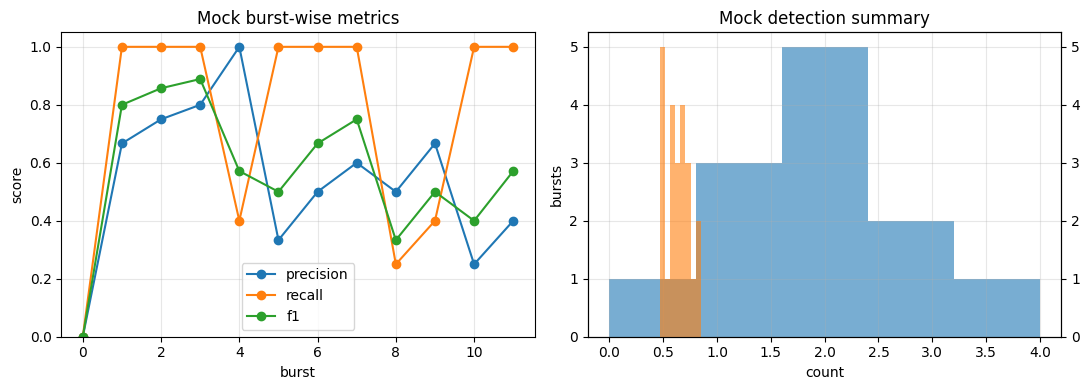

In [6]:
# Mock test with fake data and fake plots
rng = np.random.default_rng(13)

def random_box(x_range=(0, 250), y_range=(0, 250), size_range=(12, 55)):
    x1 = float(rng.uniform(*x_range))
    y1 = float(rng.uniform(*y_range))
    w = float(rng.uniform(*size_range))
    h = float(rng.uniform(*size_range))
    x2 = min(x_range[1], x1 + w)
    y2 = min(y_range[1], y1 + h)
    return np.array([x1, y1, x2, y2], dtype=float)

def make_fake_sample(n_gt: int, n_pred: int):
    gt_boxes = np.vstack([random_box() for _ in range(n_gt)])
    pred_boxes = []
    pred_scores = []

    # Make some predictions close to GT to create true positives
    for i in range(min(n_pred, n_gt)):
        box = gt_boxes[i].copy()
        jitter = rng.uniform(-8, 8, size=4)
        box = box + np.array([jitter[0], jitter[1], jitter[2], jitter[3]])
        pred_boxes.append(np.maximum(0.0, box))
        pred_scores.append(rng.uniform(0.6, 1.0))

    # Add random false positives
    for _ in range(max(0, n_pred - n_gt)):
        pred_boxes.append(random_box())
        pred_scores.append(rng.uniform(0.2, 0.9))

    pred_boxes = np.array(pred_boxes, dtype=float)
    pred_scores = np.array(pred_scores, dtype=float)
    return gt_boxes, pred_boxes, pred_scores

mock_metrics = []
for burst_id in range(12):
    gt_n = 1 + (burst_id % 5)
    pred_n = 1 + (burst_id % 4) + 1
    g, p, s = make_fake_sample(gt_n, pred_n)
    m = evaluate_frame(g, p, s, iou_threshold=0.8)
    m['burst'] = burst_id
    mock_metrics.append(m)

tp_total = sum(x['tp'] for x in mock_metrics)
fp_total = sum(x['fp'] for x in mock_metrics)
fn_total = sum(x['fn'] for x in mock_metrics)
prec_total = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0.0
rec_total = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0.0
f1_total = 2 * prec_total * rec_total / (prec_total + rec_total) if (prec_total + rec_total) else 0.0
iou_vals = [entry['iou'] for entry in sum([x['assignments'] for x in mock_metrics], [])]
mean_iou_val = float(np.mean(iou_vals)) if len(iou_vals) else 0.0

print('Mock run over 12 synthetic bursts')
print(f'TP={tp_total}, FP={fp_total}, FN={fn_total}')
print(f'Precision={prec_total:.3f}, Recall={rec_total:.3f}, F1={f1_total:.3f}, Mean matched IoU={mean_iou_val:.3f}')

burst_ids = [x['burst'] for x in mock_metrics]
precision_curve = [x['precision'] for x in mock_metrics]
recall_curve = [x['recall'] for x in mock_metrics]
f1_curve = [x['f1'] for x in mock_metrics]
tp_curve = [x['tp'] for x in mock_metrics]

fig, axis = plt.subplots(1, 2, figsize=(11, 4))
axis[0].plot(burst_ids, precision_curve, marker='o', label='precision')
axis[0].plot(burst_ids, recall_curve, marker='o', label='recall')
axis[0].plot(burst_ids, f1_curve, marker='o', label='f1')
axis[0].set_title('Mock burst-wise metrics')
axis[0].set_xlabel('burst')
axis[0].set_ylabel('score')
axis[0].set_ylim(0, 1.05)
axis[0].grid(alpha=0.3)
axis[0].legend()

axis[1].hist(tp_curve, bins=max(2, max(tp_curve)+1), alpha=0.6, label='TP/burst')
if len(iou_vals):
    axis2 = axis[1].twinx()
    axis2.hist(iou_vals, bins=8, alpha=0.6, color='tab:orange', label='matched IoU')

axis[1].set_title('Mock detection summary')
axis[1].set_xlabel('count')
axis[1].set_ylabel('bursts')
axis[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()
